# Ejercicio 4 




En este ejercicio se simula el **Correlated Wishart Orthogonal Ensemble (CWOE)** para estudiar cómo una correlación uniforme \(c\) modifica el espectro de autovalores de una matriz de covarianza.

Primero se construye la matriz de correlación poblacional \(\Xi\), con unos en la diagonal y un valor constante \(c\) fuera de ella. Posteriormente se generan matrices aleatorias gaussianas \(D\) y datos correlacionados mediante

$$
X=\Xi^{1/2}D
$$

a partir de los cuales se obtiene la matriz de covarianza muestral

$$
C=\frac{1}{T}XX^T
$$

Se realizan múltiples simulaciones para \(c=0,\;0.2,\;0.5,\;0.9\), calculando los autovalores de \(C\). La distribución obtenida numéricamente se compara con la densidad espectral teórica, analizando cómo el *bulk* se comprime conforme aumenta la correlación.

Finalmente, para \(c>0\) se estudia por separado el mayor autovalor, asociado a un **modo colectivo**, y se compara su distribución numérica con el valor teórico esperado. En conjunto, el código muestra cómo el incremento de la correlación redistribuye la varianza del sistema desde el *bulk* hacia un único modo colectivo dominante.

Primero necesitamos los valores que nos pide el ejercicio, y los colocamos hasta arriba junto con las librerias que vamos a utilizar. 

In [32]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

In [33]:
miembros = 100
N = 200
T = 500
kappa = T / N
c =  [0, 0.2, 0.5,  0.9] # Estos son los diferentes valores de c que nos pide el ejercicio. 

Ahora vamos a construir la matriz Xi con valores en la diagonal c 
Los valores de c van a variar c = 0, 0.2, 0.5 y 0.9

In [34]:
def Xi(N, c):
    Xi = np.full((N,N),c, dtype= float) 
    """Este parte de aquí nos ayuda a crear la matriz de NxN, con el full llenamos los valores de c,
    y nada más rellenamos con unos en la diagonal"""
    np.fill_diagonal(Xi, 1)
    """Esta parte de aquí nos ayuda a rellenar con unos la diagonal"""
    return Xi


Vamos a construir los datos correlacionados $X = X_{n}^{1/2}* D$
Para ello vamos a utilizar que la matriz sea generada con números aleatorios, pero con promedio cero y desviasión estándar 1. 
Podríamos crear la matriz C con una sola función, pero creo que es mejor paso a paso para no perder el hilo de lo que estamos haciendo. 

In [35]:

def matriz_D(N, T):
    D = np.random.normal(0, 1, size=(N, T))
    return D # Creamos una función que nos haga la matriz D 
def X(N,T,c):
    D = matriz_D(N, T)
    Xi_mat = Xi(N, c)
    Xi_sqrt = sqrtm(Xi_mat)
    X = Xi_sqrt @ D
    return X
    # Creamos nuestra función que haga el calculo de X, para ello necesitamos una libreria scipy.linalg 

def C(N,T,c):
    X_math = X(N,T,c)
    C = (X_math @ X_math.T) / T
    return C
    # Creamos nuestra última matriz que hará comparar los datos


Esta parte la usamos para comparar la correlación teórica con la correlación que salió, y podemos comparar la correlación empirica. Para ello vamos a calcular la traza. 
Al ejecutar el código notamos que los valores son bastante cercano a lo que que tenemos teóricos. 

In [36]:
correlaciones_empiricas = []

for i in c:

    corr_realizaciones = []

    for j in range(miembros):

        C_math = C(N, T, i) # usando el código de arriba nos da una matriz que podemos tener valores de c
        # Eliminamos los elementos diagonales
        mascara = np.eye(N, dtype=bool)
        """Nos genera una matriz de donde en la digagonal nos da los valores 'true' con eso vamos a utilizar para 
            para generar la traza. porque C_emp[mask] nos regresa los valores de a diagonal"""
        # Promedio de las correlaciones fuera de la diagonal
        c_emp = np.mean(C_math[mascara])

        corr_realizaciones.append(c_emp)

    correlaciones_empiricas.append(corr_realizaciones)

    print(f"c teórico = {i:.1f} | " f"<c empírico> = {np.mean(corr_realizaciones):.4f} | " f"std = {np.std(corr_realizaciones):.4f}"
    )

c teórico = 0.0 | <c empírico> = 1.0007 | std = 0.0043
c teórico = 0.2 | <c empírico> = 1.0006 | std = 0.0121
c teórico = 0.5 | <c empírico> = 1.0026 | std = 0.0289
c teórico = 0.9 | <c empírico> = 1.0028 | std = 0.0560


Tenemos que calcular los autovalores de nuestra matriz NxT, para ello vamos a ocupar el código de los ejercicios anteriores, usando una iteración extra, ya que vamos a sacar los autovalores de las matrices correspondientes a los valores de c   

In [37]:
autovalores_C = [[], [], [], []] # Creamos una lista con los valores de C 

for j, valor in enumerate(c): #Enumerate nos ayuda a que cada posición j-ésima jala a su valor j-ésimo de la lista
    for i in range(miembros):
        C_math = C(N,T,valor) # Generamos las matrices con nuestro código anterior. 
        autovalores = np.linalg.eigvalsh(C_math) # Calculamos los eigenvalores reales. 
        autovalores_C[j].extend(autovalores) # Los añadimos en el j-ésimo lugar de la lista
    autovalores_C[j] = np.array(autovalores_C[j]) # Los guardamos en una matriz 

Ahora vamos acrear una función sobre rho teorica, esta nos ayudará a comprar los datos de las matrices más adentale 

In [38]:
def rho_teorica(lambdas, c, kappa):
    lambda_menos = (1 - c) * (kappa**(-0.5) - 1)**2 #Creamos a las lambdas descritas por el artículo
    lambda_mas   = (1 - c) * (kappa**(-0.5) + 1)**2

    rho = np.zeros_like(lambdas) # Genera una matriz cuyas con entradas ceros de tamaño lambdas 

    mascara = (lambdas >= lambda_menos) & (lambdas <= lambda_mas) # Creamos una condición para utilizar las lambdas que vayamos a usar 
    #nos genera un arreglo con valores boleanos

    rho[mascara] = (kappa* np.sqrt((lambda_mas - lambdas[mascara]) * (lambdas[mascara] - lambda_menos)) / (2 * np.pi * (1 - c) * lambdas[mascara]))
    # A los valores que cumplan la condición los vamos a cambiar 
    return rho


Ahora podemos comparar los valores obtenidos de las matrices y usando la rho teórica. 

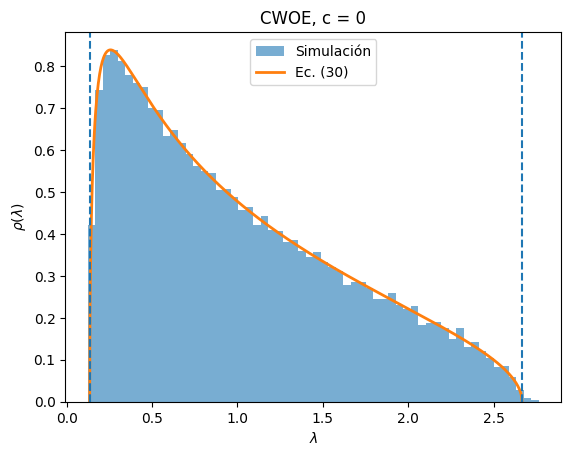

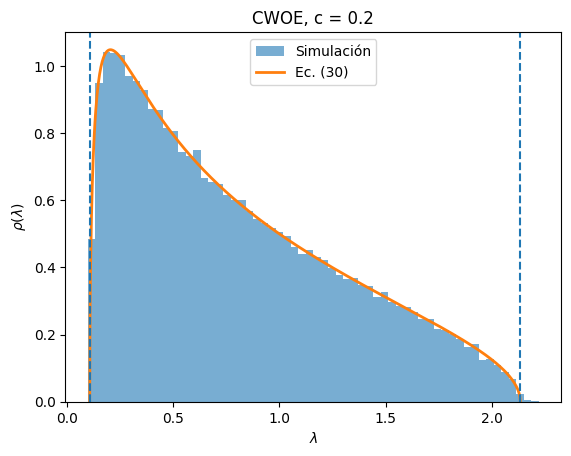

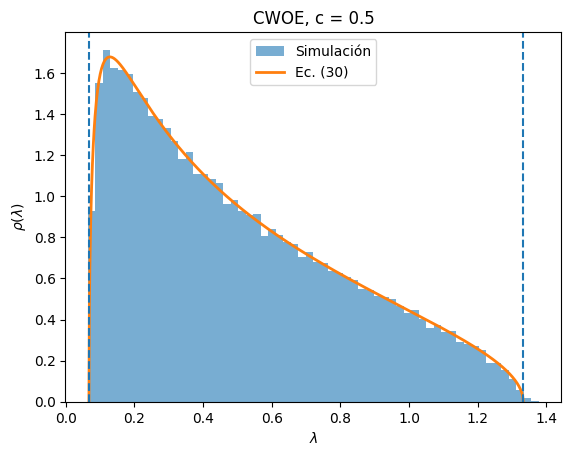

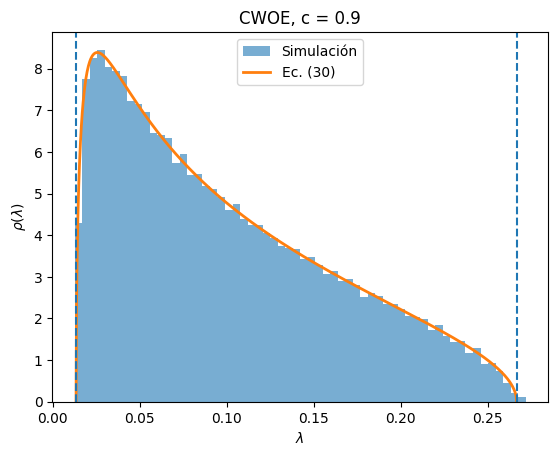

In [39]:
# plt.Figure(figsize = (10,2))
for i, ci in enumerate(c):

    # Recuperamos las 100 realizaciones de N autovalores cada una
    valores = autovalores_C[i].reshape(miembros, N) #Colocamos una matriz de 100x200

    # Para c > 0 aparece un autovalor colectivo separado
    if ci == 0:
        bulk = valores.ravel() #Creamos una matriz de una dimensión 
    else:
        bulk = valores[:, :-1].ravel()

    # Bordes teóricos
    lambda_menos = (1 - ci) * (kappa**(-0.5) - 1)**2
    lambda_mas   = (1 - ci) * (kappa**(-0.5) + 1)**2

    # Generamos de forma visual la comparación 

    lambdas = np.linspace(lambda_menos, lambda_mas, 1000)
    rho = rho_teorica(lambdas, ci, kappa)

    plt.hist(bulk, bins=60,density=True, alpha=0.6,label="Simulación")

    plt.plot( lambdas, rho, linewidth=2, label="Ec. (30)")

    plt.xlabel(r"$\lambda$")
    plt.ylabel(r"$\rho(\lambda)$")
    plt.title(f"CWOE, c = {ci}")
    plt.axvline(lambda_menos, linestyle="--")
    plt.axvline(lambda_mas, linestyle="--")
    plt.legend()
    plt.show()

Incluso podemos generar una compraración entre los diferentes valores de c

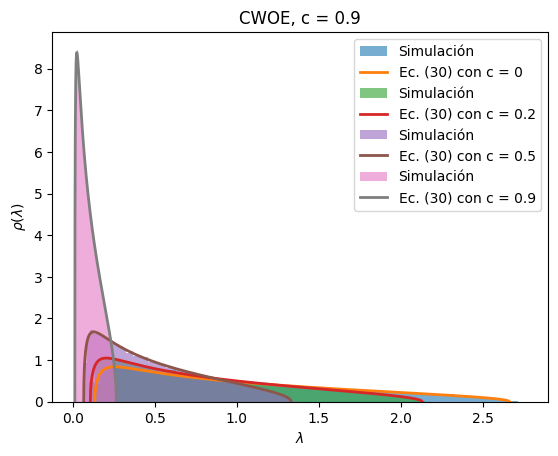

In [40]:
plt.Figure(figsize = (10,2))
for i, ci in enumerate(c):

    # Recuperamos las 100 realizaciones de N autovalores cada una
    valores = autovalores_C[i].reshape(miembros, N) #Colocamos una matriz de 100x200

    # Para c > 0 aparece un autovalor colectivo separado
    if ci == 0:
        bulk = valores.ravel() #Creamos una matriz de una dimensión 
    else:
        bulk = valores[:, :-1].ravel()

    # Bordes teóricos
    lambda_menos = (1 - ci) * (kappa**(-0.5) - 1)**2
    lambda_mas   = (1 - ci) * (kappa**(-0.5) + 1)**2

    # Generamos de forma visual la comparación 

    lambdas = np.linspace(lambda_menos, lambda_mas, 1000)
    rho = rho_teorica(lambdas, ci, kappa)

    plt.hist(bulk, bins=60,density=True, alpha=0.6,label="Simulación")

    plt.plot( lambdas, rho, linewidth=2, label=f"Ec. (30) con c = {ci}")

    plt.xlabel(r"$\lambda$")
    plt.ylabel(r"$\rho(\lambda)$")
    plt.title(f"CWOE, c = {ci}")
    #plt.axvline(lambda_menos, linestyle="--")
    #plt.axvline(lambda_mas, linestyle="--")
    plt.legend()
plt.show()

In [41]:
def lambda_colectivo(N, kappa, c):
    return ((N*c + 1 - c) * (N*c*kappa + 1 - c)) / (N*c*kappa)

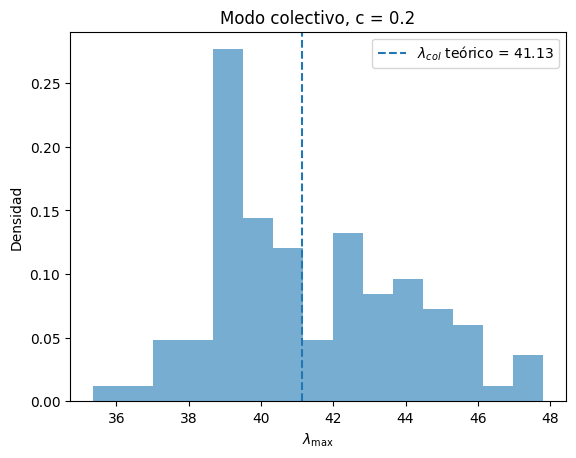

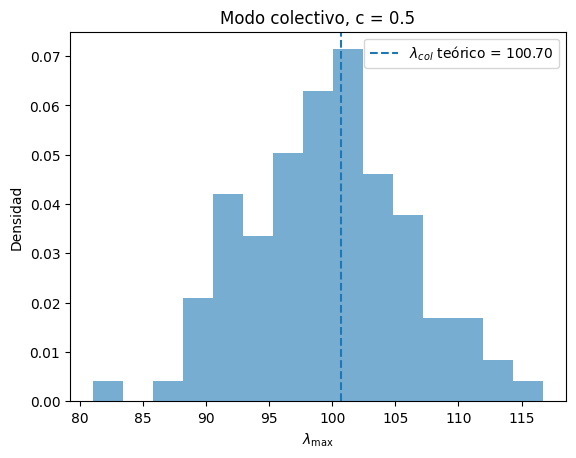

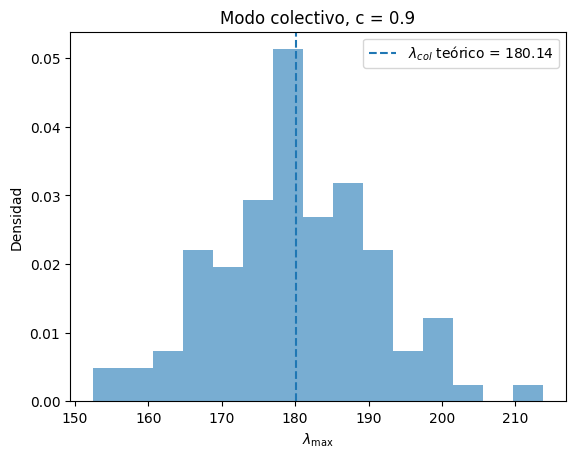

In [42]:
for i, ci in enumerate(c):

    if ci == 0:
        continue

    valores = autovalores_C[i].reshape(miembros, N)
    maximos = valores[:, -1]

    lambda_teorico = lambda_colectivo(N, kappa, ci)

    plt.hist(maximos, bins=15, density=True, alpha=0.6)
    plt.axvline(
        lambda_teorico,
        linestyle="--",
        label=fr"$\lambda_{{col}}$ teórico = {lambda_teorico:.2f}"
    )

    plt.xlabel(r"$\lambda_{\max}$")
    plt.ylabel("Densidad")
    plt.title(f"Modo colectivo, c = {ci}")
    plt.legend()
    plt.show()

# Comentario físico-matemático de los histogramas

Para \(c=0\), la matriz de correlación poblacional es la identidad,

$$
 I,
$$

por lo que las variables son estadísticamente independientes y se recupera el ensamble Wishart ortogonal no correlacionado. En este caso, la distribución de valores propios está descrita por la ley de Marchenko-Pastur.

Cuando \(c>0\), la matriz de correlación tiene la forma

$$
\Xi_{jk}=\delta_{jk}+c(1-\delta_{jk}),
$$

cuyo espectro está dado por

$$
\xi_1=\xi_2=\cdots=\xi_{N-1}=1-c,
$$

y un autovalor aislado

$$
\xi_N=1+(N-1)c.
$$

Por tanto, la presencia de correlaciones modifica el espectro en dos formas principales.

Primero, los \(N-1\) autovalores asociados al *bulk* quedan reescalados por el factor \(1-c\). Los bordes teóricos de la distribución continua son

$$
\lambda_{\pm}
=
(1-c)
\left(
\frac{1}{\sqrt{\kappa}}\pm 1
\right)^2,
\qquad
\kappa=\frac{T}{N}.
$$

Así, cuando \(c\) aumenta, el factor \(1-c\) disminuye y el *bulk* se comprime progresivamente hacia valores propios pequeños.

Segundo, aparece un autovalor separado del *bulk*, asociado a un modo colectivo. Este valor propio crece al aumentar \(c\), lo cual indica que una fracción cada vez mayor de la varianza del sistema se concentra en una única dirección común a todas las variables.

Este comportamiento puede entenderse también a partir de la traza. Como

$$
\operatorname{Tr}(\Xi)=N,
$$

la suma total de los autovalores permanece constante:

$$
\sum_{i=1}^{N}\xi_i
=
(N-1)(1-c)+\left[1+(N-1)c\right]
=
N.
$$

Por lo tanto, el aumento de las correlaciones no genera nueva varianza total, sino que redistribuye la varianza existente: el *bulk* pierde peso mientras el modo colectivo concentra una fracción creciente del espectro.

En consecuencia, para \(c=0\) no existe un modo colectivo separado y se observa únicamente el *bulk* de Marchenko-Pastur. Para valores intermedios, como \(c=0.2\) y \(c=0.5\), el *bulk* comienza a comprimirse y el autovalor máximo se separa progresivamente. Finalmente, para \(c=0.9\), el *bulk* queda fuertemente concentrado cerca de cero y el mayor autovalor domina claramente el espectro.
